In [1]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Variables
file_name= 'exam_superv.csv'
random_state = 42
np.random.seed(random_state)
df=pd.read_csv(file_name)
df.head()

,0,1,y,2
0,1.589942,2.977770,0,1.953805
1,2.908437,1.837522,1,1.510049
2,3.284091,1.818476,1,3.307287
3,3.148717,2.071991,1,3.452021
4,2.116881,2.133874,0,2.157870


### Load the dataset1.csv and explore the data, showing size, structure and histograms of numeric data; show the histogram of the frequencies of the class labels, contained in the “y” column

In [2]:
df.shape

(1200, 4)

array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
       [<Axes: title={'center': 'y'}>, <Axes: title={'center': '2'}>]],
      dtype=object)

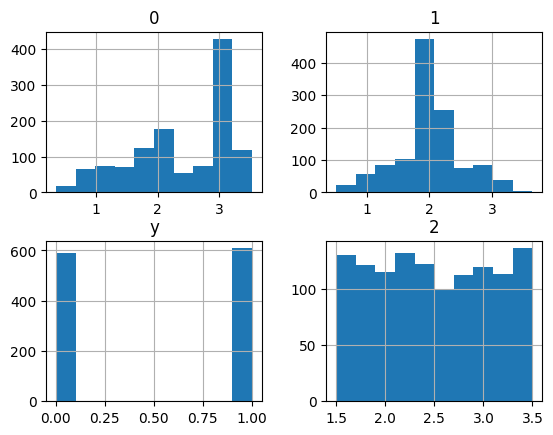

In [10]:
df.hist()

### drop the column “y” and find the best clustering scheme and hyper–parameters able to reproduce the y column (hint: before clustering youcan consider dropping columns with little correlation to “y”; perhaps you should consider more than one estimator for clustering)

<Axes: >

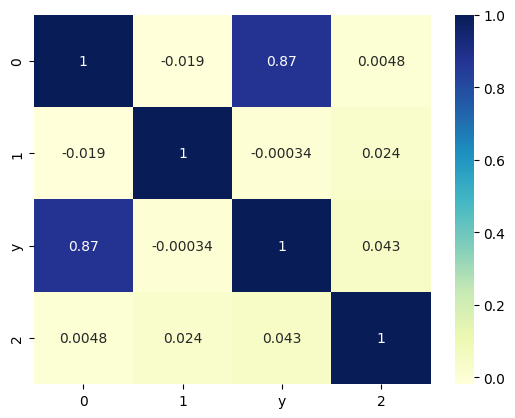

In [12]:
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, cmap="YlGnBu", annot=True)

dropping col '1' beacuse the correletion with y is very little (-0.00034)

In [38]:
df=df.drop('1', axis=1)
target_column = 'y'

# Separate in X all the columns but the last one
X = df.drop(target_column, axis = 1)

# Save the last column in y
y = df[target_column]


KeyError: "['1'] not found in axis"

In [39]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Range of possible clusters
k_range = range(2,11)

# Distortion, Silhouette Score and size deviation as measures
distortions = []
silhouette_scores = []
size_deviation = []

for i in k_range:

    # Iterate over our range of possible clusters
    km = KMeans(n_clusters = i,
                init = 'k-means++',
                n_init = 10,
                max_iter = 300,
                random_state = random_state)

    # Fit predict
    y_km = km.fit_predict(X)

    # Compute the deviation with the provided formula
    deviation = np.sqrt(np.unique(y_km, return_counts = True)[1].var())/i

    # Store the data in the arrays
    distortions.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X,y_km))
    size_deviation.append(deviation)
    km = KMeans(n_clusters=i,
            random_state=random_state)
    y_km = km.fit_predict(X)
    print("Number of clusters = {}\t- Distortion = {:6.2f}\t- Silhouette score = {:4.2f}"\
        .format(i,distortions[k_range.index(i)],silhouette_scores[k_range.index(i)]))

Number of clusters = 2	- Distortion = 581.21	- Silhouette score = 0.46
Number of clusters = 3	- Distortion = 380.32	- Silhouette score = 0.44
Number of clusters = 4	- Distortion = 264.00	- Silhouette score = 0.45
Number of clusters = 5	- Distortion = 187.55	- Silhouette score = 0.48
Number of clusters = 6	- Distortion = 153.41	- Silhouette score = 0.48
Number of clusters = 7	- Distortion = 126.18	- Silhouette score = 0.44
Number of clusters = 8	- Distortion = 107.44	- Silhouette score = 0.44
Number of clusters = 9	- Distortion =  96.00	- Silhouette score = 0.41
Number of clusters = 10	- Distortion =  85.93	- Silhouette score = 0.40


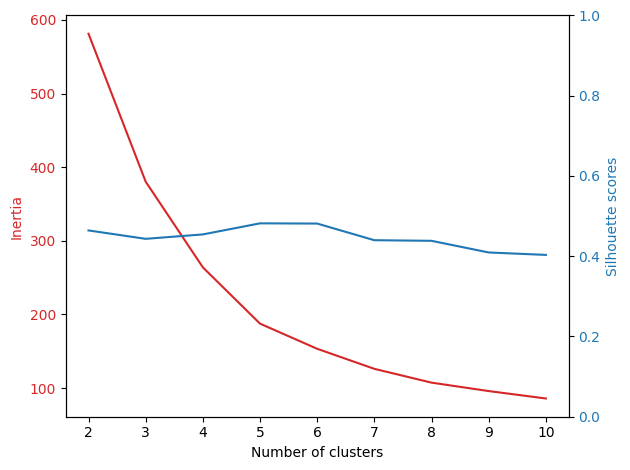

In [40]:
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('Number of clusters')
ax1.set_ylabel('Inertia', color=color)
ax1.plot(k_range, distortions, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('Silhouette scores', color=color)  # we already handled the x-label with ax1
ax2.plot(k_range, silhouette_scores, color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0,1) # the axis for silhouette is [0,1]

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

In [27]:
from sklearn.cluster import DBSCAN
from sklearn.model_selection import ParameterGrid

# !!! ATTENZIONE alla distanza tra i punti !!!
param_grid = {'eps': list(np.arange(0.01, 1, 0.01)), 'min_samples': list(range(1,10,1))}
# param_grid = {'eps': list(np.arange(60, 120, 20)), 'min_samples': list(range(5,30,5))}
params = list(ParameterGrid(param_grid))

dbscan_out = pd.DataFrame(columns = ['eps','min_samples','n_clusters', 'size deviation index','silhouette', 'unclust%'])        #0 righe, 5 colonne

for i in range(len(params)):
    db = DBSCAN(**(params[i]))
    y_db = db.fit_predict(X)
                                                                            #prende valori e filtra rumore
    cluster_labels_all = np.unique(y_db)
    cluster_labels = cluster_labels_all[cluster_labels_all != -1]
    n_clusters = len(cluster_labels)

    if n_clusters > 1:
        X_cl = X.iloc[y_db!=-1,:]                                                #filtra il rumore da X
        y_db_cl = y_db[y_db!=-1]                                            #filtra il rumore da Y

        silhouette = silhouette_score(X_cl,y_db_cl)
        deviation = np.sqrt(np.unique(y_db_cl, return_counts = True)[1].var())/i
        uncl_p = (1 - y_db_cl.shape[0]/y_db.shape[0]) * 100                 #% di dati unclustered
        dbscan_out.loc[len(dbscan_out)] = [db.eps, db.min_samples, n_clusters, deviation, silhouette, uncl_p]
        print("{:11.2f}\t{:11}\t{:11}\t{:11.2f}\t{:11.2f}\t".format(db.eps, db.min_samples, n_clusters, silhouette, uncl_p))

C:\Users\giasa\AppData\Local\Temp\ipykernel_15884\1541483314.py:24: RuntimeWarning: divide by zero encountered in scalar divide
  deviation = np.sqrt(np.unique(y_db_cl, return_counts = True)[1].var())/i


       0.01	          1	       1130	       0.08	       0.00	
       0.01	          2	         62	       0.90	      89.00	
       0.01	          3	          6	       0.97	      98.33	
       0.02	          1	        942	       0.19	       0.00	
       0.02	          2	        160	       0.71	      65.17	
       0.02	          3	         57	       0.73	      82.33	
       0.02	          4	         16	       0.81	      93.83	
       0.02	          5	          2	       0.98	      99.00	
       0.03	          1	        743	       0.23	       0.00	
       0.03	          2	        199	       0.56	      45.33	
       0.03	          3	         86	       0.53	      64.17	
       0.03	          4	         44	       0.60	      77.83	
       0.03	          5	         28	       0.67	      85.08	
       0.03	          6	          9	       0.79	      94.42	
       0.03	          7	          3	       0.90	      97.75	
       0.03	          8	          2	       0.97	      98.58	
       0.04	          1	

### show the difference between the original “y” column and the labels generated by the clustering, it can be expressed as “accuracy”, produce also the confusion matrix

In [36]:
y.unique()

array([0, 1])

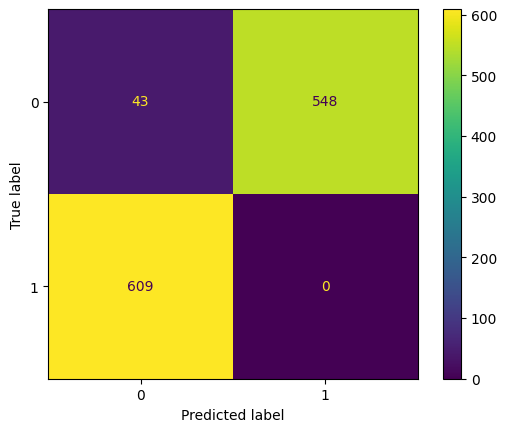

In [46]:
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.metrics.cluster import pair_confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
km = KMeans(n_clusters = 2, init = 'k-means++', n_init = 10, max_iter = 300, random_state = random_state)

# Fit and predict
y_km = km.fit_predict(X)



#Confusion matrix (Confronta valori della y)
cm = confusion_matrix(y, y_km)
CMD = ConfusionMatrixDisplay(cm)
CMD.plot()

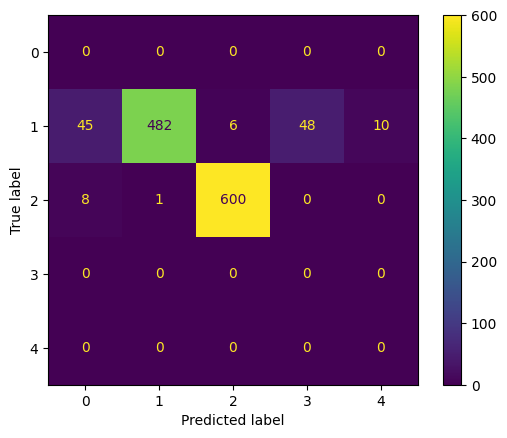

In [51]:
## CAMBIARE PARAMETRI
# Re-instantiate
db = DBSCAN(eps = 0.14, min_samples = 7)

# Fit and predict
y_db = db.fit_predict(X)
cm = confusion_matrix(y, y_db)
CMD = ConfusionMatrixDisplay(cm)
CMD.plot()